# Performance Testing Figures
Generates charts for the presentation slides from CloudWatch performance data.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

UNB_BLUE = '#002855'
UNB_LIGHT_BLUE = '#6496C8'
UNB_ORANGE = '#F39C12'
UNB_RED = '#E74C3C'
UNB_GREEN = '#27AE60'
UNB_GRAY = '#808080'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})

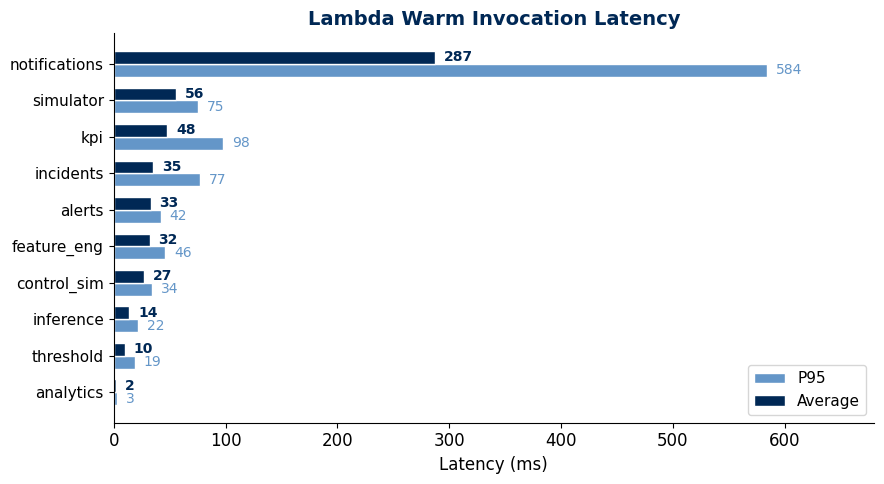

In [ ]:
# ── Figure 1: Lambda Warm Latency (Avg + P95) ──

functions = [
    'notifications', 'simulator', 'kpi', 'incidents',
    'alerts', 'feature_eng', 'control_sim',
    'inference', 'threshold', 'analytics'
]
avg_ms = [287, 56, 48, 35, 33, 32, 27, 14, 10, 2]
p95_ms = [584, 75, 98, 77, 42, 46, 34, 22, 19, 3]

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(functions))
bar_height = 0.35

bars_p95 = ax.barh(y + bar_height/2, p95_ms, bar_height,
                     label='P95', color=UNB_LIGHT_BLUE, edgecolor='white')
bars_avg = ax.barh(y - bar_height/2, avg_ms, bar_height,
                    label='Average', color=UNB_BLUE, edgecolor='white')

for bar, val in zip(bars_avg, avg_ms):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10, color=UNB_BLUE, fontweight='bold')
for bar, val in zip(bars_p95, p95_ms):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=10, color=UNB_LIGHT_BLUE)

ax.set_yticks(y)
ax.set_yticklabels(functions, fontsize=11)
ax.set_xlabel('Latency (ms)', fontsize=12)
ax.set_title('Lambda Warm Invocation Latency', fontsize=14, fontweight='bold', color=UNB_BLUE)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(0, 680)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig('figures/lambda_warm_latency.png', dpi=200, bbox_inches='tight')
plt.show()

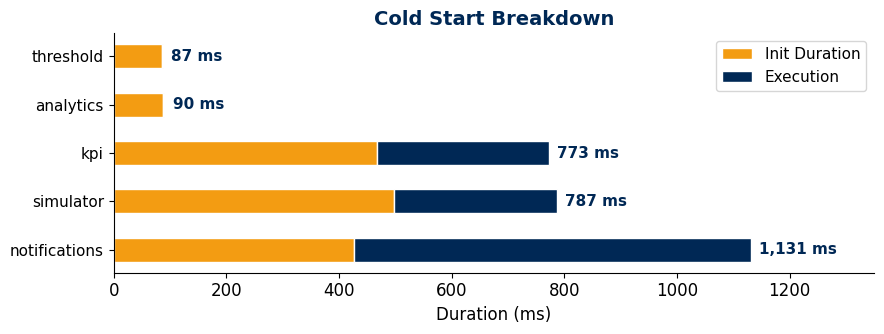

In [ ]:
# ── Figure 2: Cold Start Durations (stacked: init + execution) ──

cold_funcs = ['notifications', 'simulator', 'kpi', 'analytics', 'threshold']
init_ms    = [426, 497, 468, 88, 85]
exec_ms    = [705, 290, 305, 2, 2]  # total - init ≈ execution portion

fig, ax = plt.subplots(figsize=(9, 3.5))
y = np.arange(len(cold_funcs))

bars_init = ax.barh(y, init_ms, 0.5, label='Init Duration', color=UNB_ORANGE, edgecolor='white')
bars_exec = ax.barh(y, exec_ms, 0.5, left=init_ms, label='Execution', color=UNB_BLUE, edgecolor='white')

totals = [i + e for i, e in zip(init_ms, exec_ms)]
for i, total in enumerate(totals):
    ax.text(total + 15, i, f'{total:,} ms', va='center', fontsize=11, fontweight='bold', color=UNB_BLUE)

ax.set_yticks(y)
ax.set_yticklabels(cold_funcs, fontsize=11)
ax.set_xlabel('Duration (ms)', fontsize=12)
ax.set_title('Cold Start Breakdown', fontsize=14, fontweight='bold', color=UNB_BLUE)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, 1350)

plt.tight_layout()
fig.savefig('figures/cold_start_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()

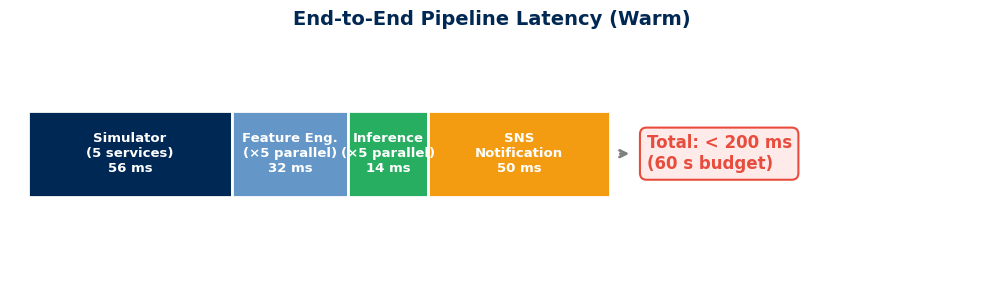

In [ ]:
# ── Figure 3: End-to-End Pipeline Timeline ──

stages =     ['Simulator\n(5 services)', 'Feature Eng.\n(×5 parallel)', 'Inference\n(×5 parallel)', 'SNS\nNotification']
durations =  [56, 32, 14, 50]
display_w =  [56, 32, 22, 50]  # bump inference from 14 to 22 for readability
colors = [UNB_BLUE, UNB_LIGHT_BLUE, UNB_GREEN, UNB_ORANGE]

fig, ax = plt.subplots(figsize=(10, 3))
left = 0
for i, (stage, dur, dw, color) in enumerate(zip(stages, durations, display_w, colors)):
    ax.barh(0, dw, left=left, height=0.5, color=color, edgecolor='white', linewidth=2)
    ax.text(left + dw/2, 0, f'{stage}\n{dur} ms', ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')
    left += dw

# Arrow between pipeline and total
ax.annotate('', xy=(left + 6, 0), xytext=(left + 2, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.text(left + 10, 0, 'Total: < 200 ms\n(60 s budget)',
        va='center', fontsize=12, fontweight='bold', color=UNB_RED,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffeaea', edgecolor=UNB_RED, linewidth=1.5))

ax.set_xlim(-5, left + 100)
ax.set_ylim(-0.7, 0.7)
ax.axis('off')
ax.set_title('End-to-End Pipeline Latency (Warm)', fontsize=14, fontweight='bold', color=UNB_BLUE)

plt.tight_layout()
fig.savefig('figures/pipeline_latency.png', dpi=200, bbox_inches='tight')
plt.show()

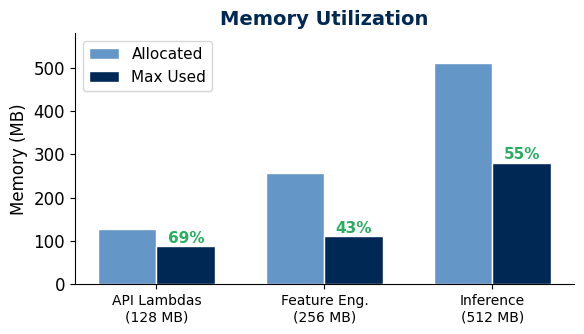

In [ ]:
# ── Figure 4: Memory Utilization ──

categories = ['API Lambdas\n(128 MB)', 'Feature Eng.\n(256 MB)', 'Inference\n(512 MB)']
allocated = [128, 256, 512]
used = [88, 111, 281]  # midpoint for API lambdas (84-92)
util_pct = [69, 43, 55]  # midpoint for API

fig, ax = plt.subplots(figsize=(6, 3.5))
x = np.arange(len(categories))
width = 0.35

bars_alloc = ax.bar(x - width/2, allocated, width, label='Allocated',
                     color=UNB_LIGHT_BLUE, edgecolor='white')
bars_used = ax.bar(x + width/2, used, width, label='Max Used',
                    color=UNB_BLUE, edgecolor='white')

for i, (bar, pct) in enumerate(zip(bars_used, util_pct)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{pct}%', ha='center', fontsize=11, fontweight='bold', color=UNB_GREEN)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Memory (MB)', fontsize=12)
ax.set_title('Memory Utilization', fontsize=14, fontweight='bold', color=UNB_BLUE)
ax.legend(fontsize=11)
ax.set_ylim(0, 580)

plt.tight_layout()
fig.savefig('figures/memory_utilization.png', dpi=200, bbox_inches='tight')
plt.show()